In this notebook we recreate the plots that were presented in 'Cosmological perturbations with ultralight vector dark matter fields: numerical implementation in CLASS'.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.interpolate import interp1d

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

### LCDM

In [2]:
# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [3]:
colors = ['#3C536D', '#DAC746', '#6E6F6D', '#DC4D57']
masses =  [1.e-25, 1.e-24, 1.e-23, 1.e-22] # eV
masses_Mpc = [mass*1.56373846613383*1.e29 for mass in masses]# Mpc^-1

# Precision overrides (previously hard-coded in include/precisions.h, now set per-notebook)
precision_settings = {
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-7,
    'k_per_decade_primordial': 30.0,
}

lcdm = Class()
lcdm_settings = {'omega_b':omega_b,
                 'Omega_cdm' : omega_cdm/h_planck**2, 'Omega_vf' : 0., 
                 'h' : h_planck,
                 'A_s' : As,
                 'n_s':ns,
                 'tau_reio':tau_reio,
                 'YHe': 'BBN','output':'tCl,pCl, mPk','gauge':'synchronous',
                 'ic' : 'ad', 'z_pk' : '0,20',
                 'modes' : 's', 'recombination' : 'RECFAST'}
lcdm_settings.update(precision_settings)
lcdm.set(lcdm_settings)

lcdm.compute()
all_k_lcdm = lcdm.get_perturbations()
background_lcdm = lcdm.get_background()

frac = 1-1.e-6
common_settings  = {
            'h' : h_planck, 
            'omega_b' : omega_b,
            'Omega_cdm' : omega_cdm*(1-frac)/h_planck**2,
            'N_ncdm' : 0.,
            'Omega_fld' : 0.,
            'Omega_vf' : frac*omega_cdm/h_planck**2,
            'attractor_ic_vf' : 'yes',
            'vector_background_mode': 'bianchi',
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'output' : 'tCl,pCl,mPk',
            'ic' : 'ad', 'z_pk' : '0,20',
            'gauge' : 'synchronous',
            'A_s' : As,
            'n_s' : ns,
            'modes' : 's',
            'recombination' : 'RECFAST'
            }
common_settings.update(precision_settings) 

As a benchmark, let's define the LCDM cosmology.

## Porcentual Errors

### Small Masses

In [4]:
small_masses = [1.e-25, 1.e-24, 1.e-23, 1.e-22]
small_masses_Mpc = [mass*1.56373846613383*1.e29 for mass in small_masses]# Mpc^-1
k_smallm_max = 1.e1
lcdm_smallm = Class()
lcdm_smallm.set(lcdm_settings)
lcdm_smallm.set({'P_k_max_h/Mpc':k_smallm_max})
lcdm_smallm.compute()

cosmo_small_mass_0 = {}
cosmo_small_mass_pi2 = {}
for m in range(len(small_masses)):

    cosmo_small_mass_0[m] = Class()
    cosmo_small_mass_0[m].set(common_settings)
    cosmo_small_mass_0[m].set({'P_k_max_h/Mpc' : k_smallm_max})
    cosmo_small_mass_0[m].set({'vf_mass' : '%s'%small_masses[m]})
    cosmo_small_mass_0[m].set({'vector_background_mode' : 'bianchi'})
    cosmo_small_mass_0[m].set({'gamma_Ak': 0})
    cosmo_small_mass_0[m].compute()

    cosmo_small_mass_pi2[m] = Class()
    cosmo_small_mass_pi2[m].set(common_settings)
    cosmo_small_mass_pi2[m].set({'P_k_max_h/Mpc' : k_smallm_max})
    cosmo_small_mass_pi2[m].set({'vf_mass' : '%s'%small_masses[m]})
    cosmo_small_mass_pi2[m].set({'vector_background_mode' : 'bianchi'})
    cosmo_small_mass_pi2[m].set({'gamma_Ak': np.pi/2})
    cosmo_small_mass_pi2[m].compute()

    print(small_masses[m])

1e-25
1e-24
1e-23
1e-22


/home/tomaschase/miniconda3/envs/class_env/lib/python3.9/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


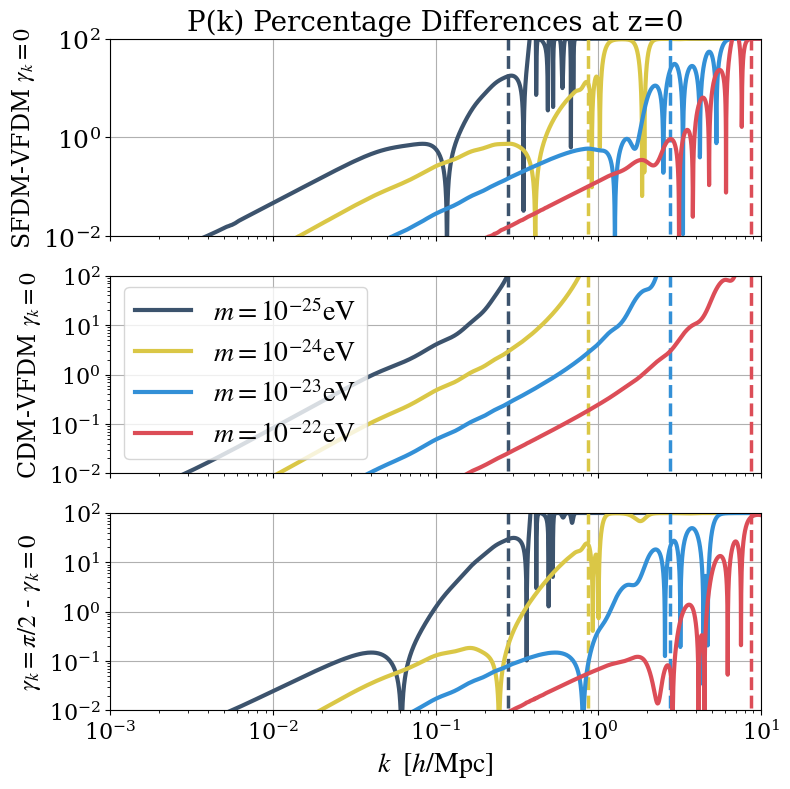

/home/tomaschase/miniconda3/envs/class_env/lib/python3.9/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


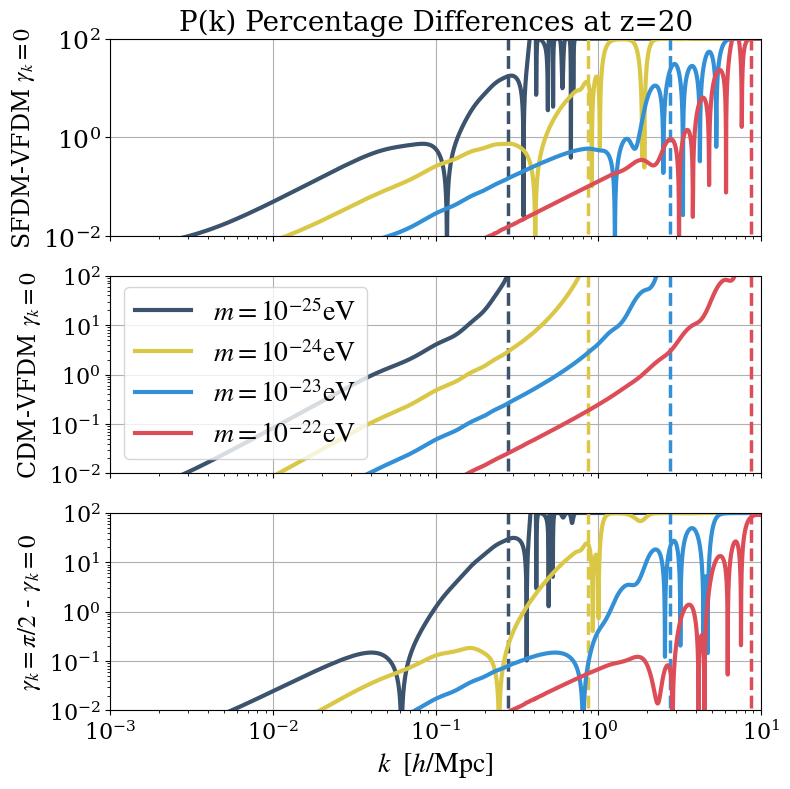

In [5]:
def Pk_scalar_porcentual_small_m(z0):
    colors_plot = ['#3C536D', '#DAC746', '#3390D7', '#DC4D57']
    fig, axes = plt.subplots(3,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [1, 1, 1]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(small_masses)):

        kk = np.logspace(-3,1,5000) # k in h/Mpc

        Pk_thetapi2 = [] # P(k) in (Mpc/h)**3
        Pk_theta0 = []
        Pk_lcdm = [] # P(k) in (Mpc/h)**3
        data_scf = np.loadtxt('../../SFDM_data/delta_scf/Pk_scf_errors_m=%s_z=%s'% (str(small_masses[m])[-3:],str(z0))) # P(k) in (Mpc/h)**3
        Pk_scalar = data_scf[:,1]  # second column

        h0 = cosmo_small_mass_0[m].h() # get reduced Hubble for conversions to 1/Mpc 
        hpi2 = cosmo_small_mass_pi2[m].h()
        h_lcdm = lcdm_smallm.h() # get reduced Hubble for conversions to 1/Mpc

        background = cosmo_small_mass_0[m].get_background() 
        background_z = background['z'] # read redshift
        background_a = 1/(1+background_z)

        background_H_over_m = background['H [1/Mpc]']/small_masses_Mpc[m] # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kJ =  a_osc * np.sqrt(small_masses_Mpc[m] * H_osc) /h0

        for k in kk:
            Pk_theta0.append(cosmo_small_mass_0[m].pk(k*h0,z0)*h0**3) # function .pk(k,z)
            Pk_thetapi2.append(cosmo_small_mass_pi2[m].pk(k*hpi2,z0)*hpi2**3) # function .pk(k,z)
            Pk_lcdm.append(lcdm_smallm.pk(k*h_lcdm,z0)*h_lcdm**3) # function .pk(k,z)
            
        axes[0].loglog(kk, 100*np.abs(1-(np.array(Pk_scalar)/np.array(Pk_theta0))), color=colors_plot[m], lw=3)
        axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk_lcdm)/np.array(Pk_theta0))), color=colors_plot[m], label=r'$m=10^{%s}\rm{eV}$'% str(small_masses[m])[-3:], lw=3)
        axes[2].loglog(kk, 100*np.abs(1-(np.array(Pk_thetapi2)/np.array(Pk_theta0))), color=colors_plot[m], lw=3)

        axes[0].axvline(kJ, ymin=1.e-2, ymax=1.e2, color=colors_plot[m], linestyle='dashed', lw=2.5)
        axes[1].axvline(kJ, ymin=1.e-2, ymax=1.e2, color=colors_plot[m], linestyle='dashed', lw=2.5)
        axes[2].axvline(kJ, ymin=1.e-2, ymax=1.e2, color=colors_plot[m], linestyle='dashed', lw=2.5)
    axes[0].set_ylim([1.e-2, 1.e2])
    axes[1].set_ylim([1.e-2, 1.e2])
    axes[2].set_ylim([1.e-2, 1.e2])
    axes[1].set_xlim([1.e-3, 1.e1])
    axes[2].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=20)
    axes[0].set_ylabel(r'SFDM-VFDM $\gamma_k=0$', size=17)
    axes[1].set_ylabel(r'CDM-VFDM $\gamma_k=0$', size=17)
    axes[2].set_ylabel(r'$\gamma_k=\pi/2$ - $\gamma_k=0$', size=18)
    axes[0].set_title('P(k) Percentage Differences at z=%s'%str(z0), size=20)
    axes[1].legend(loc='lower left', fontsize=20)
    axes[0].tick_params(axis='both',labelsize=18)
    axes[1].tick_params(labelsize=16)
    axes[2].tick_params(labelsize=16)
    fig.tight_layout()
    plt.grid()
    plt.savefig('../../Figures/Pk_Porcentual_errors_small_masses_z=%s.pdf'%str(z0), format='pdf')
    plt.savefig('../../Figures/Pk_Porcentual_errors_small_masses_z=%s.png'%str(z0), format='png')
    plt.show()

Pk_scalar_porcentual_small_m(0)
Pk_scalar_porcentual_small_m(20)

### Big Masses

In [6]:
big_masses = [1.e-21, 1.e-20, 1.e-19, 1.e-18]
big_masses_Mpc = [mass*1.56373846613383*1.e29 for mass in big_masses]# Mpc^-1
k_bigm_max = 1.e3

precision_settings = {
    'start_small_k_at_tau_c_over_tau_h': 0.0015,
    'start_large_k_at_tau_h_over_tau_k': 0.07,
    'tol_perturbations_integration': 1.e-5,
    'k_per_decade_primordial': 10.0,
}

lcdm_settings.update(precision_settings)

lcdm_bigm = Class()
lcdm_bigm.set(lcdm_settings)
lcdm_bigm.set({'P_k_max_h/Mpc':k_bigm_max})
lcdm_bigm.compute()

common_settings.update(precision_settings) 

cosmo_big_mass_0 = {}
cosmo_big_mass_pi2 = {}
for m in range(len(big_masses)):
 
    cosmo_big_mass_0[m] = Class()
    cosmo_big_mass_0[m].set(common_settings)
    cosmo_big_mass_0[m].set({'P_k_max_h/Mpc' : k_bigm_max})
    cosmo_big_mass_0[m].set({'vf_mass' : '%s'%big_masses[m]})
    cosmo_big_mass_0[m].set({'vector_background_mode' : 'bianchi'})
    cosmo_big_mass_0[m].set({'gamma_Ak': 0})
    cosmo_big_mass_0[m].compute()

    cosmo_big_mass_pi2[m] = Class()
    cosmo_big_mass_pi2[m].set(common_settings)
    cosmo_big_mass_pi2[m].set({'P_k_max_h/Mpc' : k_bigm_max})
    cosmo_big_mass_pi2[m].set({'vf_mass' : '%s'%big_masses[m]})
    cosmo_big_mass_pi2[m].set({'vector_background_mode' : 'bianchi'})
    cosmo_big_mass_pi2[m].set({'gamma_Ak': np.pi/2})
    cosmo_big_mass_pi2[m].compute()

    print(big_masses[m])

1e-21
1e-20
1e-19
1e-18


/home/tomaschase/miniconda3/envs/class_env/lib/python3.9/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


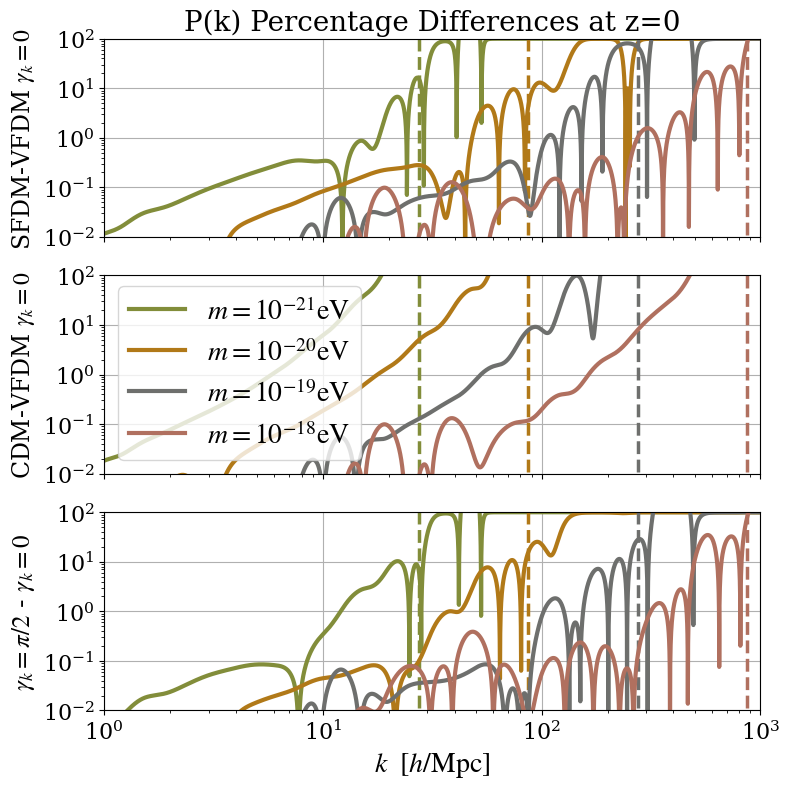

/home/tomaschase/miniconda3/envs/class_env/lib/python3.9/site-packages/matplotlib/scale.py:255: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


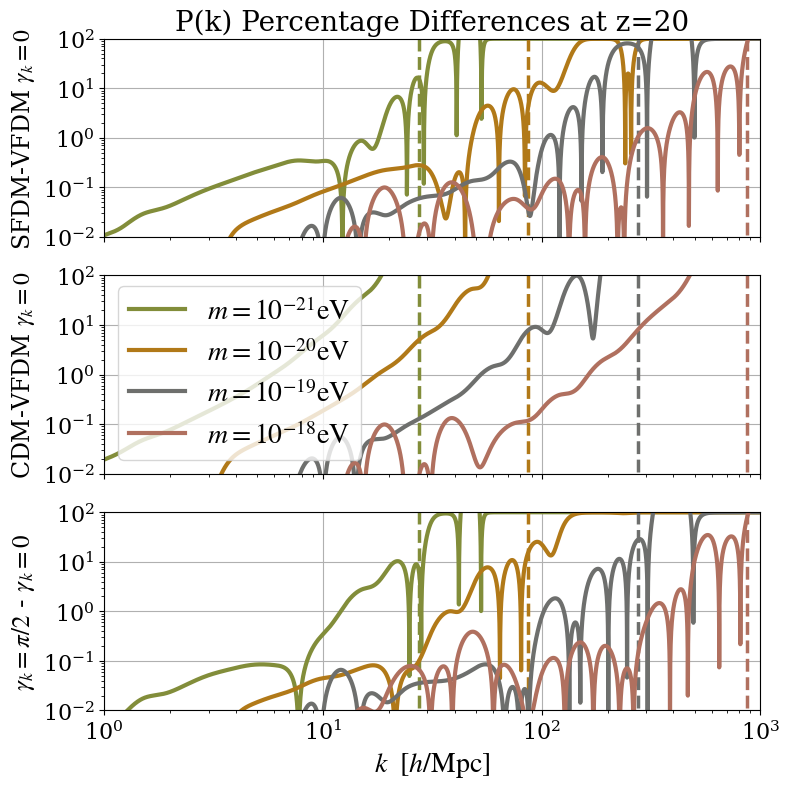

In [7]:
def Pk_scalar_porcentual_big_m(z0):
    color_plots = ['#828D3A', '#B17918', '#6E6F6D', '#B0705F']
    fig, axes = plt.subplots(3,1,sharex=True, figsize=(8, 8), gridspec_kw={'height_ratios': [1, 1, 1]})

    for i in range(2):
        axes[i].grid()

    for m in range(len(big_masses)):

        kk = np.logspace(0,np.log10(k_bigm_max),5000) # k in h/Mpc

        Pk_thetapi2 = [] # P(k) in (Mpc/h)**3
        Pk_theta0 = []
        Pk_lcdm = [] # P(k) in (Mpc/h)**3
        data_scf = np.loadtxt('../../SFDM_data/delta_scf/Pk_scf_errors_m=%s_z=%s'% (str(big_masses[m])[-3:],z0)) # P(k) in (Mpc/h)**3
        Pk_scalar = data_scf[:,1]  # second column
        h0 = cosmo_big_mass_0[m].h() # get reduced Hubble for conversions to 1/Mpc 
        hpi2 = cosmo_big_mass_pi2[m].h()
        h_lcdm = lcdm_bigm.h() # get reduced Hubble for conversions to 1/Mpc

        background = cosmo_big_mass_0[m].get_background() 
        background_z = background['z'] # read redshift
        background_a = 1/(1+background_z)
        background_H_over_m = background['H [1/Mpc]']/big_masses_Mpc[m] # read k/aH = k(1+z)/H
        a_osc = interp1d(background_H_over_m, background_a)(1.)
        H_osc = interp1d(background_H_over_m, background['H [1/Mpc]'])(1.)

        kJ =  a_osc * np.sqrt(big_masses_Mpc[m] * H_osc) /h0


        for k in kk:
            Pk_theta0.append(cosmo_big_mass_0[m].pk(k*h0,z0)*h0**3) # function .pk(k,z)
            Pk_thetapi2.append(cosmo_big_mass_pi2[m].pk(k*hpi2,z0)*hpi2**3) # function .pk(k,z)
            Pk_lcdm.append(lcdm_bigm.pk(k*h_lcdm,z0)*h_lcdm**3) # function .pk(k,z)
            
        axes[0].loglog(kk, 100*np.abs(1-(np.array(Pk_scalar)/np.array(Pk_theta0))), color=color_plots[m], lw=3)
        axes[1].loglog(kk, 100*np.abs(1-(np.array(Pk_lcdm)/np.array(Pk_theta0))), color=color_plots[m], label=r'$m=10^{%s}\rm{eV}$'% str(big_masses[m])[-3:], lw=3)
        axes[2].loglog(kk, 100*np.abs(1-(np.array(Pk_thetapi2)/np.array(Pk_theta0))), color=color_plots[m], lw=3)
        
        axes[0].axvline(kJ, ymin=1.e-2, ymax=1.e2, color=color_plots[m], linestyle='dashed', lw=2.5)
        axes[1].axvline(kJ, ymin=1.e-2, ymax=1.e2, color=color_plots[m], linestyle='dashed', lw=2.5)
        axes[2].axvline(kJ, ymin=1.e-2, ymax=1.e2, color=color_plots[m], linestyle='dashed', lw=2.5)
    axes[0].set_ylim([1.e-2, 1.e2])
    axes[1].set_ylim([1.e-2, 1.e2])
    axes[2].set_ylim([1.e-2, 1.e2])
    axes[1].set_xlim([1.e0, k_bigm_max])
    axes[2].set_xlabel(r'$k \,\,\,\, [h/\mathrm{Mpc}]$', size=20)
    axes[0].set_ylabel(r'SFDM-VFDM $\gamma_k=0$', size=17)
    axes[1].set_ylabel(r'CDM-VFDM $\gamma_k=0$', size=17)
    axes[2].set_ylabel(r'$\gamma_k=\pi/2$ - $\gamma_k=0$', size=18)
    axes[0].set_title('P(k) Percentage Differences at z=%s'%str(z0), size=20)
    axes[1].legend(loc='lower left', fontsize=20)
    axes[0].tick_params(axis='both',labelsize=16)
    axes[1].tick_params(labelsize=16)
    axes[2].tick_params(labelsize=16)
    plt.grid()
    fig.tight_layout()
    plt.savefig('../../Figures/Pk_Porcentual_errors_big_masses_z=%s.pdf'%str(z0), format='pdf')
    plt.savefig('../../Figures/Pk_Porcentual_errors_big_masses_z=%s.png'%str(z0), format='png')
    plt.show()

Pk_scalar_porcentual_big_m(0)
Pk_scalar_porcentual_big_m(20)